## GDELT Tests

for this test we are using the GDELT Api and trying to recreate commands inspired here: https://drkblake.com/gdeltintro/ 

a "query" that worked in our favour and was a good start on the web api was: https://api.gdeltproject.org/api/v2/doc/doc?query=%22Quantum%20Computing%22%20&mode=timelinevolinfo&startdatetime=20200101090000&enddatetime=20260420090000
this means Quantum computing (topic) --- timelinevolinfos(the timeline graph) --- form the 01.01.2020 - 20.04.2026

the entire thing takes a while hence the API slowed down significantly over time 

### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from gdeltdoc import GdeltDoc, Filters,near, repeat
import time
from gdeltdoc.errors import RateLimitError
from datetime import datetime, timedelta


### Testcode

code from the GDELT 2.0 Doc API Client github

pip install gdeltdoc

USE: The ArtList and Timeline* query modes are supported.

In [ ]:
f = Filters(
    keyword = "brain-computer interface",
    start_date = "2020-05-10",
    end_date = "2020-05-11"
)

gd = GdeltDoc()

# Search for articles matching the filters
#articles = gd.article_search(f)

#time.sleep(10)

# Get a timeline of the number of articles matching the filters
timeline = gd.timeline_search("timelinevol", f)

print(timeline.head())
#print(articles.head())

In [ ]:
# Convert date
timeline['datetime'] = pd.to_datetime(timeline['datetime'])

# Plot
plt.figure(figsize=(12,6))
plt.plot(timeline['datetime'], timeline['Volume Intensity'])
plt.title("Quantum Computing Media Coverage (2020–2026)")
plt.xlabel("Date")
plt.ylabel("Relative Coverage (%)")
plt.grid(True)
plt.show()

## Test one day Quantum computing

test with chat gpt for maybe later pipeline

In [ ]:
gd = GdeltDoc()

f = Filters(
    keyword="quantum computing",
    start_date="2020-05-10",
    end_date="2020-05-11"
)

timeline = gd.timeline_search("timelinevol", f)

df = pd.DataFrame(timeline)

print(df.head())
print(df.columns)
print(df.shape)


                   datetime  Volume Intensity
0 2020-05-10 00:00:00+00:00               0.0
1 2020-05-10 00:15:00+00:00               0.0
2 2020-05-10 00:30:00+00:00               0.0
3 2020-05-10 00:45:00+00:00               0.0
4 2020-05-10 01:00:00+00:00               0.0
Index(['datetime', 'Volume Intensity'], dtype='str')
(97, 2)


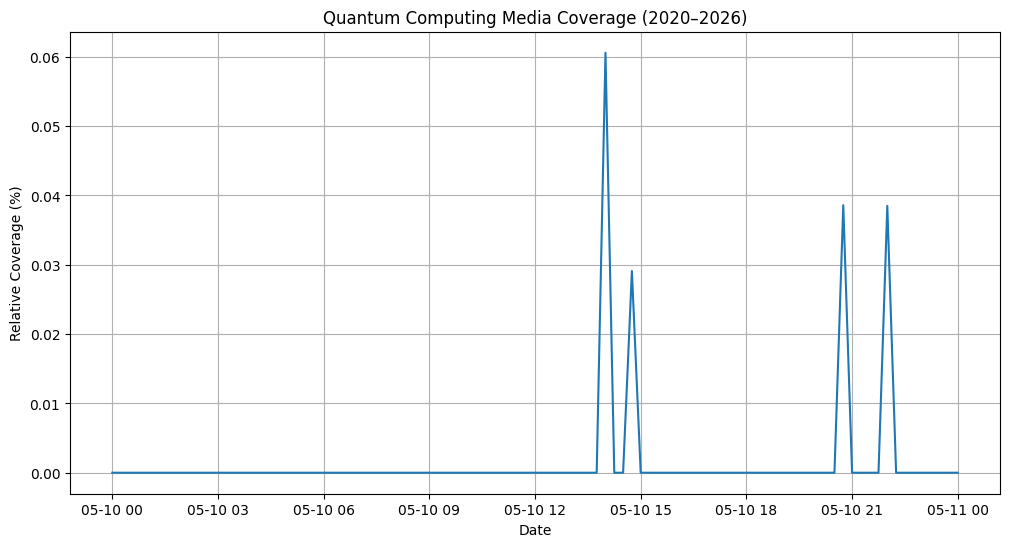

In [4]:
# Convert date
df['datetime'] = pd.to_datetime(df['datetime'])

# Plot
plt.figure(figsize=(12,6))
plt.plot(df['datetime'], df['Volume Intensity'])
plt.title("Quantum Computing Media Coverage (2020–2026)")
plt.xlabel("Date")
plt.ylabel("Relative Coverage (%)")
plt.grid(True)
plt.show()

In [5]:
df["datetime"] = pd.to_datetime(df["datetime"])

daily = (
    df
    .set_index("datetime")
    .resample("D")["Volume Intensity"]
    .mean()
    .reset_index()
)

print(daily)

                   datetime  Volume Intensity
0 2020-05-10 00:00:00+00:00          0.001738
1 2020-05-11 00:00:00+00:00          0.000000


In [6]:
daily = df.copy()

daily["datetime"] = pd.to_datetime(daily["datetime"])
daily["date"] = daily["datetime"].dt.date

daily = daily.groupby("date")["Volume Intensity"].mean().reset_index()
daily.columns = ["date", "volume"]

print(daily)

         date    volume
0  2020-05-10  0.001738
1  2020-05-11  0.000000


## Test with larger time 2 Years

In [11]:
gd = GdeltDoc()

f = Filters(
    keyword="quantum computing",
    start_date="2020-05-10",
    end_date="2022-05-11"
)

timeline = gd.timeline_search("timelinevol", f)

df = pd.DataFrame(timeline)

print(df.head())
print(df.columns)
print(df.shape)


                   datetime  Volume Intensity
0 2020-05-10 00:00:00+00:00            0.0018
1 2020-05-11 00:00:00+00:00            0.0054
2 2020-05-12 00:00:00+00:00            0.0171
3 2020-05-13 00:00:00+00:00            0.0090
4 2020-05-14 00:00:00+00:00            0.0093
Index(['datetime', 'Volume Intensity'], dtype='str')
(731, 2)


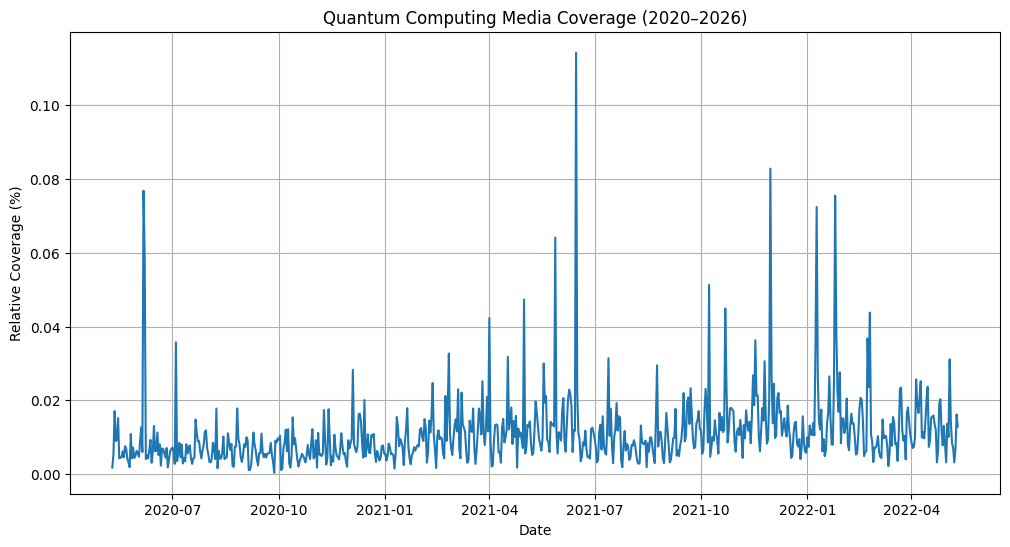

In [12]:
# Convert date
df['datetime'] = pd.to_datetime(df['datetime'])

# Plot
plt.figure(figsize=(12,6))
plt.plot(df['datetime'], df['Volume Intensity'])
plt.title("Quantum Computing Media Coverage (2020–2026)")
plt.xlabel("Date")
plt.ylabel("Relative Coverage (%)")
plt.grid(True)
plt.show()

## Test form 2020- today

In [11]:
gd = GdeltDoc()
curr_date= (datetime.today() - timedelta(days=1)).strftime("%Y-%m-%d") #Yesterday for full data
#curr_date = datetime.today().strftime("%Y-%m-%d") #actually today but might be incomplete
#print(curr_date)

f = Filters(
    keyword="quantum computing",
    start_date="2020-01-01",
    end_date=curr_date
)
articles = gd.article_search(f)

time.sleep(60)

timeline = gd.timeline_search("timelinevol", f)

df = pd.DataFrame(timeline)
articles 
print(df.head())
print(df.columns)
print(df.shape)

                   datetime  Volume Intensity
0 2020-01-01 00:00:00+00:00            0.0106
1 2020-01-02 00:00:00+00:00            0.0082
2 2020-01-03 00:00:00+00:00            0.0094
3 2020-01-04 00:00:00+00:00            0.0066
4 2020-01-05 00:00:00+00:00            0.0162
Index(['datetime', 'Volume Intensity'], dtype='str')
(2298, 2)


In [13]:
articles

,url,url_mobile,title,seendate,socialimage,domain,language,sourcecountry
0,https://www.fool.com/investing/2026/05/04/why-...,,Why D - Wave Quantum Stock Jumped 40 % Last Month,20260504T154500Z,https://g.foolcdn.com/editorial/images/868581/...,fool.com,English,United States
1,https://www.fool.com/investing/2026/03/11/3-to...,,3 Top Quantum Computing Stocks to Buy in March,20260311T183000Z,https://g.foolcdn.com/editorial/images/857258/...,fool.com,English,United States
2,https://finance.yahoo.com/news/3-top-quantum-c...,,3 Top Quantum Computing Stocks to Buy in March,20260313T060000Z,https://s.yimg.com/os/en/motleyfool.com/ff2769...,finance.yahoo.com,English,United States
3,https://www.insidermonkey.com/blog/8-best-quan...,https://www.insidermonkey.com/blog/8-best-quan...,8 Best Quantum Computing Stocks to Buy and Hol...,20260504T133000Z,https://d2gr5kl7dt2z3t.cloudfront.net/blog/wp-...,insidermonkey.com,English,United States
4,https://www.techtimes.com/articles/315859/2026...,,Why Quantum Computing Will Transform Technolog...,20260415T114500Z,https://d.techtimes.com/en/full/464046/quantum...,techtimes.com,English,United States
...,...,...,...,...,...,...,...,...
245,https://finance.yahoo.com/news/put-1-000-high-...,,"Should You Put $1 , 000 Into This High - Risk ...",20260205T054500Z,https://s.yimg.com/ny/api/res/1.2/kC6a4tkXUIBo...,finance.yahoo.com,English,United States
246,https://www.fool.com/investing/2026/04/13/3-un...,,3 Under - the - Radar AI Stock Picks That Coul...,20260413T063000Z,https://g.foolcdn.com/editorial/images/863875/...,fool.com,English,United States
247,https://www.newscientist.com/article/2517490-p...,,Phantom codes could help quantum computers avo...,20260303T203000Z,https://images.newscientist.com/wp-content/upl...,newscientist.com,English,United States
248,https://finance.yahoo.com/markets/stocks/artic...,,Should You Buy Rigetti Computing Stock While I...,20260324T150000Z,https://s.yimg.com/ny/api/res/1.2/O8f_eBEp2h3D...,finance.yahoo.com,English,United States


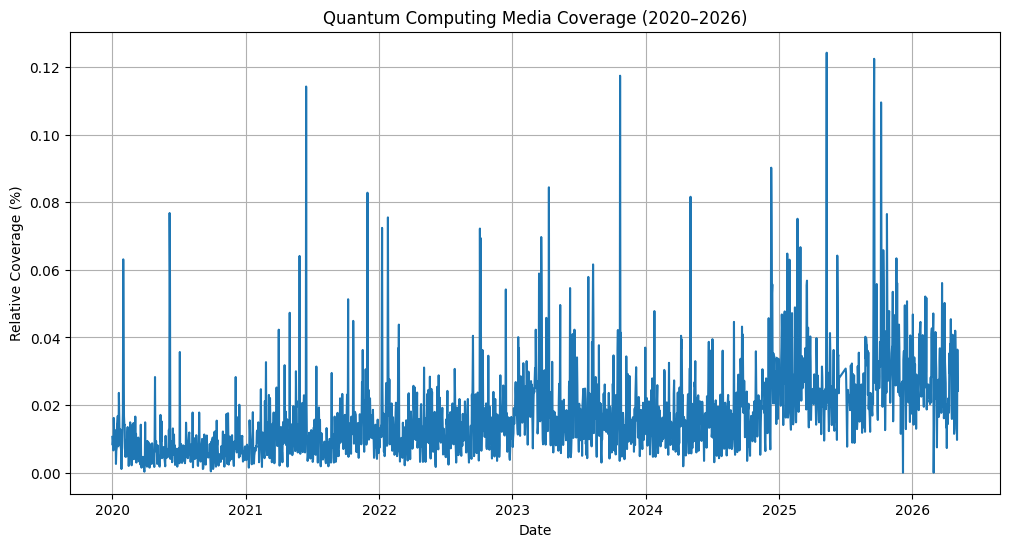

In [12]:
# Convert date
df['datetime'] = pd.to_datetime(df['datetime'])

# Plot
plt.figure(figsize=(12,6))
plt.plot(df['datetime'], df['Volume Intensity'])
plt.title("Quantum Computing Media Coverage (2020–2026)")
plt.xlabel("Date")
plt.ylabel("Relative Coverage (%)")
plt.grid(True)
plt.show()